In [1]:
# ======================
# INSTALL + IMPORTS
# ======================
!pip install ultralytics --quiet

import os, json, random, shutil, logging
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc, f1_score

logging.getLogger("ultralytics").setLevel(logging.WARNING)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [2]:
# ======================
# PATHS
# ======================
DATASET_PATH = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"
PREPROC_PATH = "/kaggle/input/datasets/harshitabansal307/task2-preprocessed-detetcion-segmentation/preprocessed"

DATASET_DIR = "/kaggle/working/yolo_dataset"
os.makedirs(DATASET_DIR, exist_ok=True)

EPOCHS     = 8
BATCH_SIZE = 16
IMG_SIZE   = 416

In [3]:
# ======================
# LOAD DATA
# ======================
train_samples = torch.load(os.path.join(PREPROC_PATH, "train_detection_samples_balanced.pt"))
val_samples   = torch.load(os.path.join(PREPROC_PATH, "val_detection_samples_balanced.pt"))
category_map  = torch.load(os.path.join(PREPROC_PATH, "category_map.pt"))
class_weights = torch.load(os.path.join(PREPROC_PATH, "class_weights.pt"))

print("category_map:", category_map)
print("class_weights:", class_weights)

category_map: {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}
class_weights: tensor([0.0217, 0.6984, 0.9034, 1.3665, 1.3874, 1.6227])


In [4]:
# ── CLASS NAMES ────────────────────────────────────────────────────────────────
# Labels in .pt files are ALREADY 1-5 from preprocessing 
# YOLO expects 0-based class indices, so we subtract 1: label 1->0, 2->1, etc.
# CLASS_NAMES[i] corresponds to YOLO class index i (= raw label i+1).
# ──────────────────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    "short sleeve top",   # raw label 1 -> YOLO class 0
    "trousers",           # raw label 2 -> YOLO class 1
    "shorts",             # raw label 3 -> YOLO class 2
    "long sleeve top",    # raw label 4 -> YOLO class 3
    "skirt"               # raw label 5 -> YOLO class 4
]

NUM_CLASSES = len(CLASS_NAMES)

# Valid raw labels (1-5). Anything outside this is skipped (e.g. stray label 5
# that doesn't appear in category_map, or any other unexpected value).
VALID_LABELS = set(range(1, NUM_CLASSES + 1))

def raw_label_to_yolo(label):
    """Convert raw label (1-5) to YOLO 0-based class index."""
    return int(label) - 1

def yolo_to_raw_label(yolo_cls):
    """Convert YOLO 0-based class index back to raw label (1-5)."""
    return int(yolo_cls) + 1

print(f"Valid raw labels: {VALID_LABELS}")
print(f"Mapping: raw label -> YOLO index: { {l: raw_label_to_yolo(l) for l in VALID_LABELS} }")

Valid raw labels: {1, 2, 3, 4, 5}
Mapping: raw label -> YOLO index: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


In [5]:
# ======================
# CREATE SEGMENTATION DATASET
# ======================
def create_dataset():
    print("\n[CREATING DATASET]")

    for split, samples in [("train", train_samples), ("val", val_samples)]:
        img_dir   = f"{DATASET_DIR}/{split}/images"
        label_dir = f"{DATASET_DIR}/{split}/labels"
        os.makedirs(img_dir,   exist_ok=True)
        os.makedirs(label_dir, exist_ok=True)

        skipped = 0
        for i, s in enumerate(tqdm(samples, desc=split)):
            img_path = s["img_path"]
            if not os.path.exists(img_path):
                skipped += 1
                continue

            name       = f"{split}_{i:06d}"
            dest_img   = f"{img_dir}/{name}.jpg"
            dest_label = f"{label_dir}/{name}.txt"

            # Skip already-processed samples (safe for re-runs)
            if os.path.exists(dest_img) and os.path.exists(dest_label):
                continue

            # Symlink instead of copy: much faster, saves disk space
            if not os.path.exists(dest_img):
                os.symlink(os.path.abspath(img_path), dest_img)

            img = Image.open(img_path)
            w, h = img.size

            lines = []
            for label, polys in zip(s["labels"], s["polygons"]):
                # ── KEY FIX ──────────────────────────────────────────────────
                # Skip unknown labels (e.g. label=5 not in category_map, or
                # any other out-of-range value). 
                #   if int(label) not in category_map: continue
                # ─────────────────────────────────────────────────────────────
                if int(label) not in VALID_LABELS:
                    continue

                cls = raw_label_to_yolo(label)   # 1->0, 2->1, 3->2, 4->3, 5->4

                for poly in polys:
                    if len(poly) < 6:
                        continue

                    coords = []
                    for j in range(0, len(poly) - 1, 2):
                        # Normalize only if values look like pixel coords
                        x = poly[j]   / w if poly[j]   > 1.0 else poly[j]
                        y = poly[j+1] / h if poly[j+1] > 1.0 else poly[j+1]
                        coords.append(min(max(x, 0.0), 1.0))
                        coords.append(min(max(y, 0.0), 1.0))

                    if len(coords) >= 6:
                        lines.append(f"{cls} " + " ".join(f"{c:.6f}" for c in coords))

            if not lines:
                skipped += 1
                if os.path.exists(dest_img):
                    os.remove(dest_img)
                continue

            with open(dest_label, "w") as f:
                f.write("\n".join(lines))

        print(f"  {split}: skipped {skipped} samples")

create_dataset()


[CREATING DATASET]


train: 100%|██████████| 20000/20000 [03:32<00:00, 94.06it/s]


  train: skipped 0 samples


val: 100%|██████████| 5000/5000 [01:09<00:00, 71.50it/s] 

  val: skipped 0 samples


In [6]:
# ======================
# YAML
# ======================
yaml_path = f"{DATASET_DIR}/data.yaml"

with open(yaml_path, "w") as f:
    f.write(f"""
path: {DATASET_DIR}
train: train/images
val:   val/images
nc:    {NUM_CLASSES}
names: {CLASS_NAMES}
""")

In [7]:
# ======================
# CLASS WEIGHTS for YOLO
# class_weights.pt has weights indexed 1-5 (matching raw labels).
# YOLO cls_pw expects a single scalar or per-class tensor indexed 0-4.
# We reindex: weight for YOLO class i = class_weights[i+1]
# ======================
# cls_pw_tensor shape should be (NUM_CLASSES,) for per-class weighting
cls_pw_values = [float(class_weights[i+1]) for i in range(NUM_CLASSES)]
print("YOLO class weights (0-indexed):", cls_pw_values)

YOLO class weights (0-indexed): [0.6983832716941833, 0.9033792614936829, 1.3664791584014893, 1.3873940706253052, 1.6226608753204346]


In [8]:
# ======================
# TRAIN  (transfer learning from COCO pretrained weights)
# NOTE: yolov8n-seg.pt = pretrained — intentional, NOT from scratch.
#       For scratch training use YOLO("yolov8n-seg.yaml") instead.
# ======================
model = YOLO("yolov8n-seg.pt")

from ultralytics.utils import callbacks

def on_train_epoch_end(trainer):
    e     = trainer.epoch + 1
    total = trainer.epochs
    loss  = trainer.loss.item() if hasattr(trainer.loss, 'item') else float(trainer.loss)
    print(f"Epoch {e}/{total} — loss: {loss:.4f}")

model.add_callback("on_train_epoch_end", on_train_epoch_end)

model.train(
    data         = yaml_path,
    epochs       = EPOCHS,
    batch        = BATCH_SIZE,
    imgsz        = IMG_SIZE,
    device       = DEVICE,
    # ── Augmentation (matching UNet/MaskRCNN) ───────────────────────────────
    mosaic       = 0.5,
    fliplr       = 0.5,        
    cls          = 0.5,        # classification loss weight
    # ── Speed-up knobs ──────────────────────────────────────────────────────
    workers      = 8,
    cache        = "disk",      # cache images in RAM (use "disk" if RAM < 16 GB)
    amp          = True,       # FP16 mixed precision: ~2x faster on GPU
    close_mosaic = 2,          # disable mosaic for last 2 epochs
    verbose      = False,
)

best_model = YOLO(model.trainer.best)

WARNING ⚠️ train: 42.8GB disk space required, with 50% safety margin but only 19.3/19.5GB free, not caching images to disk
val: Caching images (6.6GB Disk): 100% ━━━━━━━━━━━━ 5000/5000 268.1it/s 18.7s
Epoch 1/8 — loss: 115.3982
Epoch 2/8 — loss: 106.1479
Epoch 3/8 — loss: 105.3245
Epoch 4/8 — loss: 104.9273
Epoch 5/8 — loss: 97.8553
Epoch 6/8 — loss: 96.0735
Epoch 7/8 — loss: 76.7174
Epoch 8/8 — loss: 83.4219


In [9]:
# ============================================================================
#  SECTION 1 — YOLO NATIVE mAP  (COCO-style mAP@[0.5:0.95])
# ============================================================================
val_results = best_model.val(data=yaml_path)

box     = val_results.box
seg_yolo = val_results.seg

det_map_overall  = float(box.map)
det_map50        = float(box.map50)
det_map75        = float(box.map75)
det_map_per_cls  = {CLASS_NAMES[i]: float(v) for i, v in enumerate(box.maps)}

seg_map_overall  = float(seg_yolo.map)
seg_map50        = float(seg_yolo.map50)
seg_map_per_cls  = {CLASS_NAMES[i]: float(v) for i, v in enumerate(seg_yolo.maps)}

print("\n" + "="*60)
print("DETECTION")
print(f"  mAP@[0.5:0.95] : {det_map_overall:.4f}")
print(f"  mAP@0.50       : {det_map50:.4f}")
print(f"  mAP@0.75       : {det_map75:.4f}")
print(f"  Per-class mAP  : { {k: round(v,4) for k,v in det_map_per_cls.items()} }")

print("\nSEGMENTATION (YOLO native)")
print(f"  mAP@[0.5:0.95] : {seg_map_overall:.4f}")
print(f"  mAP@0.50       : {seg_map50:.4f}")
print(f"  Per-class mAP  : { {k: round(v,4) for k,v in seg_map_per_cls.items()} }")


DETECTION
  mAP@[0.5:0.95] : 0.5264
  mAP@0.50       : 0.6475
  mAP@0.75       : 0.6025
  Per-class mAP  : {'short sleeve top': 0.5911, 'trousers': 0.4698, 'shorts': 0.3962, 'long sleeve top': 0.4576, 'skirt': 0.7173}

SEGMENTATION (YOLO native)
  mAP@[0.5:0.95] : 0.2089
  mAP@0.50       : 0.3813
  Per-class mAP  : {'short sleeve top': 0.3501, 'trousers': 0.0031, 'shorts': 0.0031, 'long sleeve top': 0.0984, 'skirt': 0.5898}


seg mIoU/Dice: 100%|██████████| 5000/5000 [02:21<00:00, 35.37it/s]



Class                    mIoU     Dice
----------------------------------------
short sleeve top       0.5986   0.6630
trousers               0.5176   0.5991
shorts                 0.4648   0.5351
long sleeve top        0.4956   0.5678
skirt                  0.5422   0.5981
----------------------------------------
MACRO                  0.5238   0.5926


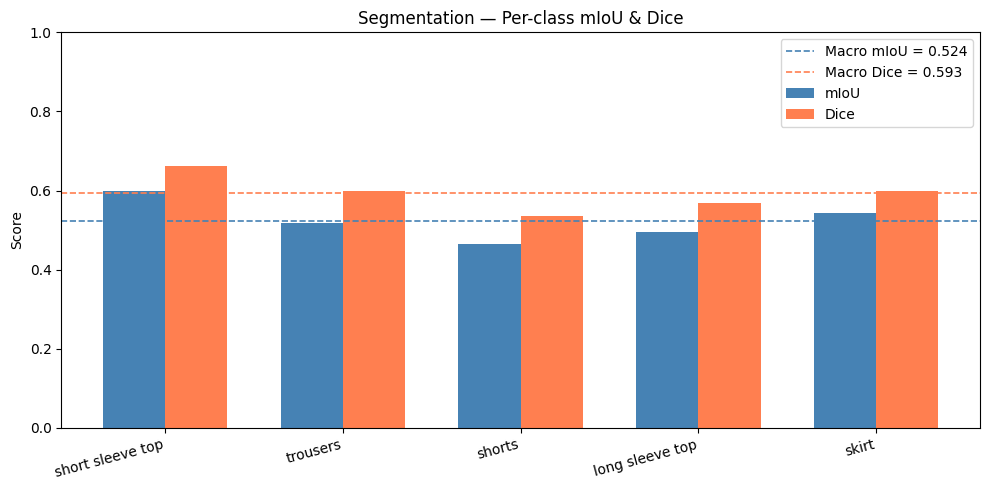

In [10]:
# ============================================================================
#  SECTION 2 — SEGMENTATION  mIoU + Dice  (per-class + macro)
# ============================================================================
def compute_segmentation_metrics(model, samples):
    iou_per_class  = {c: [] for c in range(NUM_CLASSES)}
    dice_per_class = {c: [] for c in range(NUM_CLASSES)}

    for s in tqdm(samples, desc="seg mIoU/Dice"):
        if not os.path.exists(s["img_path"]):
            continue

        img = Image.open(s["img_path"])
        w, h = img.size

        # Ground-truth pixel mask using raw labels directly (1-5), same as UNet
        gt = np.zeros((h, w), dtype=np.uint8)
        for label, polys in zip(s["labels"], s["polygons"]):
            if int(label) not in VALID_LABELS:
                continue
            cls_gt = raw_label_to_yolo(label)   # 0-4
            for p in polys:
                pts = np.array(p).reshape(-1, 2).astype(int)
                cv2.fillPoly(gt, [pts], cls_gt + 1)   # store as 1-5 in gt mask

        r    = model.predict(s["img_path"], verbose=False)[0]
        pred = np.zeros((h, w), dtype=np.uint8)

        if r.masks is not None:
            for m, cls in zip(r.masks.data.cpu().numpy(),
                              r.boxes.cls.cpu().numpy()):
                m = cv2.resize(m, (w, h))
                pred[m > 0.5] = int(cls) + 1   # YOLO 0-4 -> stored as 1-5

        for cls in range(NUM_CLASSES):
            gt_c   = (gt   == cls + 1)
            pred_c = (pred == cls + 1)
            inter  = np.logical_and(gt_c, pred_c).sum()
            union  = np.logical_or(gt_c, pred_c).sum()

            if union > 0:
                iou_per_class[cls].append(inter / (union + 1e-7))
                dice_per_class[cls].append(
                    2 * inter / (gt_c.sum() + pred_c.sum() + 1e-7)
                )

    iou_scores  = [np.mean(iou_per_class[c])  if iou_per_class[c]  else 0.0
                   for c in range(NUM_CLASSES)]
    dice_scores = [np.mean(dice_per_class[c]) if dice_per_class[c] else 0.0
                   for c in range(NUM_CLASSES)]

    macro_iou  = float(np.mean(iou_scores))
    macro_dice = float(np.mean(dice_scores))

    # Pretty-print table (matches UNet output style)
    print("\n" + "="*60)
    print(f"{'Class':<20} {'mIoU':>8} {'Dice':>8}")
    print("-"*40)
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name:<20} {iou_scores[i]:>8.4f} {dice_scores[i]:>8.4f}")
    print("-"*40)
    print(f"{'MACRO':<20} {macro_iou:>8.4f} {macro_dice:>8.4f}")

    # Bar chart
    x  = np.arange(NUM_CLASSES)
    bw = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - bw/2, iou_scores,  bw, label="mIoU", color="steelblue")
    ax.bar(x + bw/2, dice_scores, bw, label="Dice", color="coral")
    ax.axhline(macro_iou,  color="steelblue", linestyle="--", linewidth=1.2,
               label=f"Macro mIoU = {macro_iou:.3f}")
    ax.axhline(macro_dice, color="coral",     linestyle="--", linewidth=1.2,
               label=f"Macro Dice = {macro_dice:.3f}")
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Segmentation — Per-class mIoU & Dice")
    ax.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/seg_iou_dice.png", dpi=150)
    plt.show()

    return {
        "mIoU_per_class": {CLASS_NAMES[i]: round(v, 4) for i, v in enumerate(iou_scores)},
        "dice_per_class": {CLASS_NAMES[i]: round(v, 4) for i, v in enumerate(dice_scores)},
        "mIoU_macro":     round(macro_iou,  4),
        "dice_macro":     round(macro_dice, 4),
    }

seg_metrics = compute_segmentation_metrics(best_model, val_samples)

det ROC/AUC/F1: 100%|██████████| 5000/5000 [01:37<00:00, 51.21it/s]



Class                     AUC   F1@0.5
----------------------------------------
short sleeve top       0.9467   0.8494
trousers               0.9613   0.8522
shorts                 0.9327   0.8004
long sleeve top        0.9547   0.8244
skirt                  0.9426   0.8375
----------------------------------------
MACRO                  0.9476   0.8766


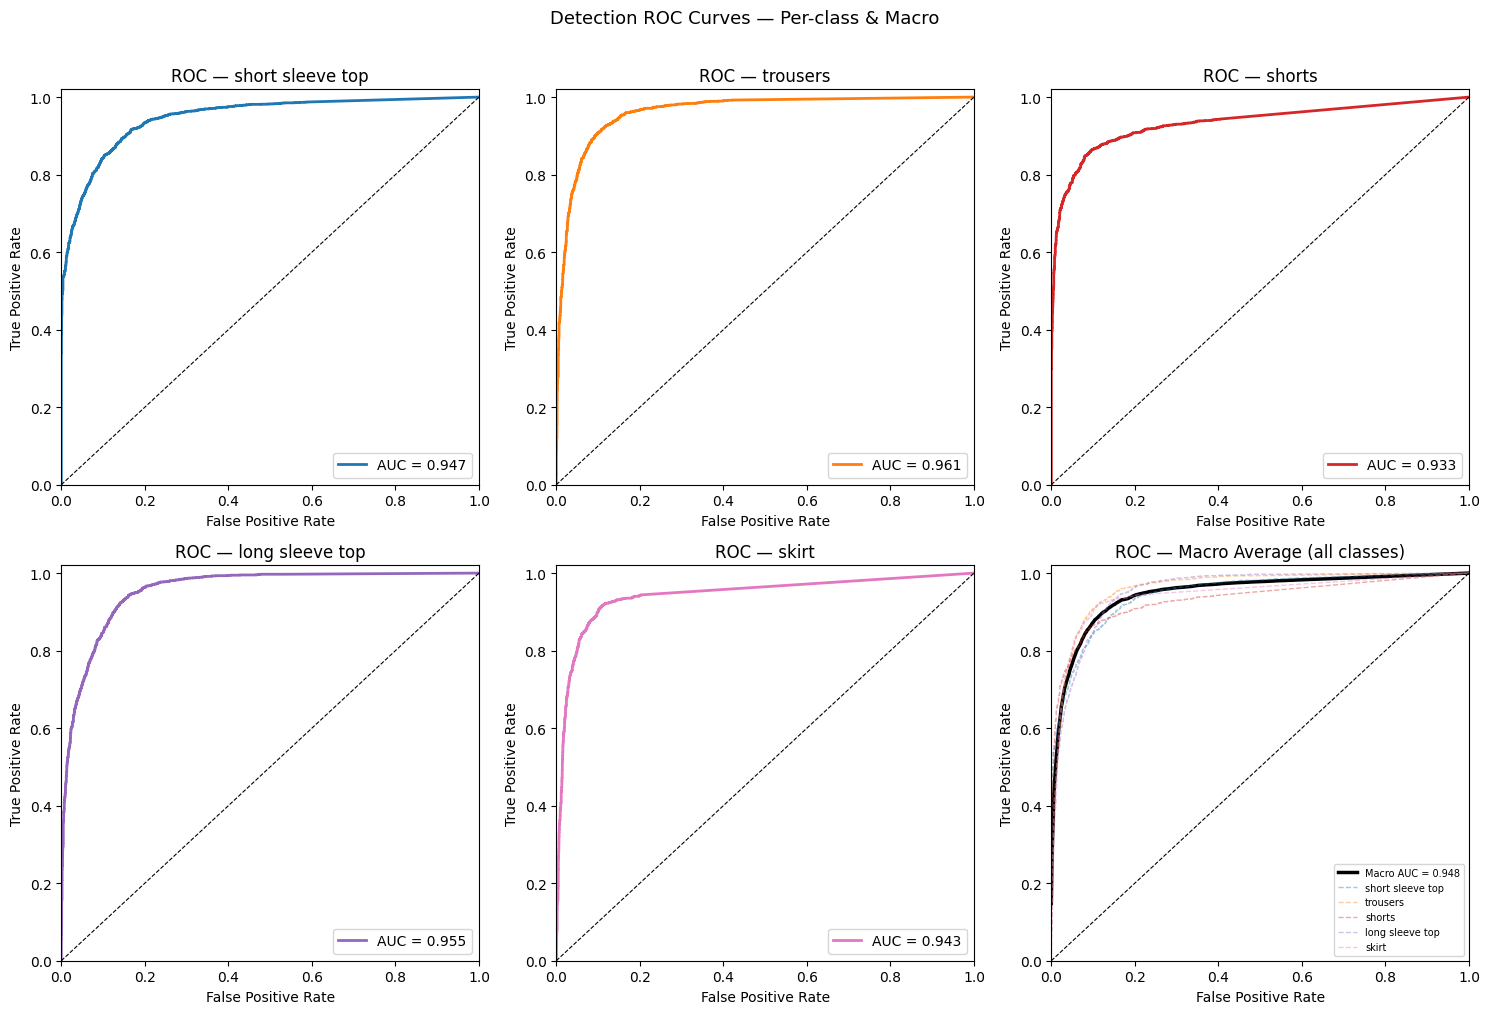

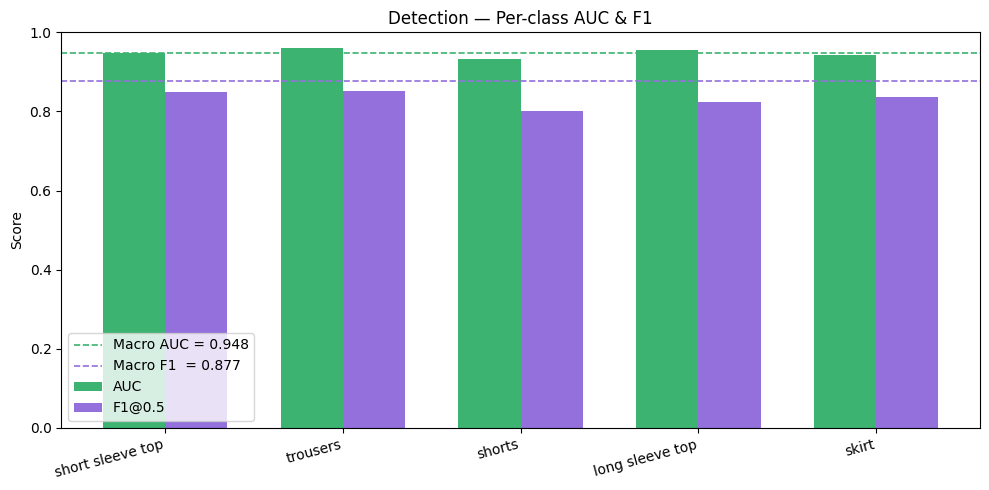

In [11]:
# ============================================================================
#  SECTION 3 — DETECTION  ROC + AUC + F1  (per-class AND macro)
# ============================================================================
def compute_detection_metrics(model, samples):
    y_true_cls  = {c: [] for c in range(NUM_CLASSES)}
    y_score_cls = {c: [] for c in range(NUM_CLASSES)}

    for s in tqdm(samples, desc="det ROC/AUC/F1"):
        if not os.path.exists(s["img_path"]):
            continue

        # conf=0.01 to retain low-confidence predictions for full ROC range
        r     = model.predict(s["img_path"], conf=0.01, verbose=False)[0]
        preds = r.boxes.cls.cpu().numpy()  if len(r.boxes) > 0 else np.array([])
        confs = r.boxes.conf.cpu().numpy() if len(r.boxes) > 0 else np.array([])

        # GT: raw labels 1-5 -> YOLO 0-4
        gts = {raw_label_to_yolo(l) for l in s["labels"] if int(l) in VALID_LABELS}

        for cls in range(NUM_CLASSES):
            y_true_cls[cls].append(int(cls in gts))
            matching = [c for p, c in zip(preds, confs) if int(p) == cls]
            y_score_cls[cls].append(float(max(matching, default=0.0)))

    # Per-class ROC, AUC, F1
    per_class_results = {}
    all_fpr = {}
    all_tpr = {}

    print("\n" + "="*60)
    print(f"{'Class':<20} {'AUC':>8} {'F1@0.5':>8}")
    print("-"*40)

    for cls in range(NUM_CLASSES):
        yt  = np.array(y_true_cls[cls])
        ys  = np.array(y_score_cls[cls])
        yp  = (ys >= 0.5).astype(int)

        fpr, tpr, _ = roc_curve(yt, ys)
        auc_score   = auc(fpr, tpr)
        f1          = float(f1_score(yt, yp, zero_division=0))

        all_fpr[cls] = fpr
        all_tpr[cls] = tpr

        per_class_results[CLASS_NAMES[cls]] = {
            "AUC": round(auc_score, 4),
            "F1":  round(f1, 4),
        }
        print(f"{CLASS_NAMES[cls]:<20} {auc_score:>8.4f} {f1:>8.4f}")

    # Macro-averaged ROC
    mean_fpr   = np.linspace(0, 1, 500)
    tpr_matrix = np.array([
        np.interp(mean_fpr, all_fpr[c], all_tpr[c]) for c in range(NUM_CLASSES)
    ])
    mean_tpr  = tpr_matrix.mean(axis=0)
    macro_auc = float(auc(mean_fpr, mean_tpr))

    y_true_flat = np.concatenate([y_true_cls[c] for c in range(NUM_CLASSES)])
    y_pred_flat = np.concatenate(
        [(np.array(y_score_cls[c]) >= 0.5).astype(int) for c in range(NUM_CLASSES)]
    )
    macro_f1 = float(f1_score(y_true_flat, y_pred_flat, average="macro", zero_division=0))

    print("-"*40)
    print(f"{'MACRO':<20} {macro_auc:>8.4f} {macro_f1:>8.4f}")

    # Plot: per-class ROC grid + macro panel (matches UNet roc output style)
    colors = plt.cm.tab10(np.linspace(0, 0.6, NUM_CLASSES))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for cls in range(NUM_CLASSES):
        ax = axes[cls]
        ax.plot(all_fpr[cls], all_tpr[cls], color=colors[cls], lw=2,
                label=f"AUC = {per_class_results[CLASS_NAMES[cls]]['AUC']:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=0.8)
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"ROC — {CLASS_NAMES[cls]}")
        ax.legend(loc="lower right")

    ax = axes[NUM_CLASSES]
    ax.plot(mean_fpr, mean_tpr, color="black", lw=2.5,
            label=f"Macro AUC = {macro_auc:.3f}")
    for cls in range(NUM_CLASSES):
        ax.plot(all_fpr[cls], all_tpr[cls], color=colors[cls],
                lw=1, alpha=0.4, linestyle="--", label=CLASS_NAMES[cls])
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC — Macro Average (all classes)")
    ax.legend(loc="lower right", fontsize=7)

    plt.suptitle("Detection ROC Curves — Per-class & Macro", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("/kaggle/working/det_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Bar chart: per-class AUC and F1
    auc_vals = [per_class_results[n]["AUC"] for n in CLASS_NAMES]
    f1_vals  = [per_class_results[n]["F1"]  for n in CLASS_NAMES]
    x  = np.arange(NUM_CLASSES)
    bw = 0.35
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.bar(x - bw/2, auc_vals, bw, label="AUC",    color="mediumseagreen")
    ax2.bar(x + bw/2, f1_vals,  bw, label="F1@0.5", color="mediumpurple")
    ax2.axhline(macro_auc, color="mediumseagreen", linestyle="--", linewidth=1.2,
                label=f"Macro AUC = {macro_auc:.3f}")
    ax2.axhline(macro_f1,  color="mediumpurple",   linestyle="--", linewidth=1.2,
                label=f"Macro F1  = {macro_f1:.3f}")
    ax2.set_xticks(x)
    ax2.set_xticklabels(CLASS_NAMES, rotation=15, ha="right")
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Score")
    ax2.set_title("Detection — Per-class AUC & F1")
    ax2.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/det_auc_f1.png", dpi=150)
    plt.show()

    return {
        "mAP_50_95_overall":   round(det_map_overall, 4),
        "mAP_50_overall":      round(det_map50, 4),
        "mAP_75_overall":      round(det_map75, 4),
        "mAP_50_95_per_class": {k: round(v, 4) for k, v in det_map_per_cls.items()},
        "AUC_macro":           round(macro_auc, 4),
        "F1_macro":            round(macro_f1,  4),
        "per_class":           per_class_results,
    }

det_metrics = compute_detection_metrics(best_model, val_samples)


[VISUALIZATION]


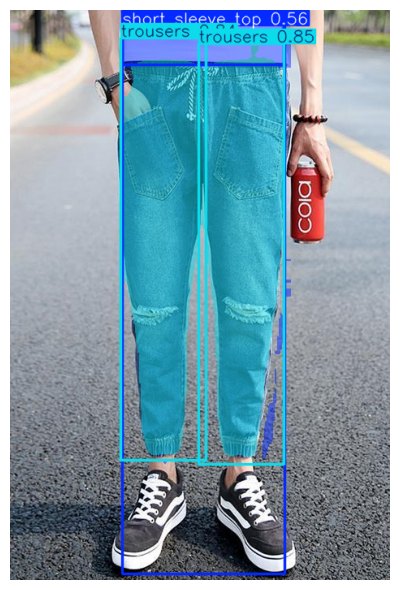

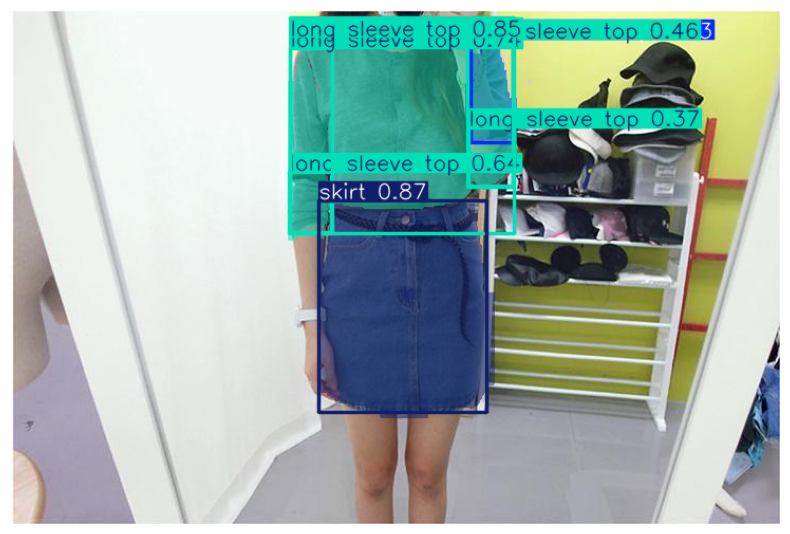


FINAL REPORT:
{
  "detection": {
    "mAP_50_95_overall": 0.5264,
    "mAP_50_overall": 0.6475,
    "mAP_75_overall": 0.6025,
    "mAP_50_95_per_class": {
      "short sleeve top": 0.5911,
      "trousers": 0.4698,
      "shorts": 0.3962,
      "long sleeve top": 0.4576,
      "skirt": 0.7173
    },
    "AUC_macro": 0.9476,
    "F1_macro": 0.8766,
    "per_class": {
      "short sleeve top": {
        "AUC": 0.9467,
        "F1": 0.8494
      },
      "trousers": {
        "AUC": 0.9613,
        "F1": 0.8522
      },
      "shorts": {
        "AUC": 0.9327,
        "F1": 0.8004
      },
      "long sleeve top": {
        "AUC": 0.9547,
        "F1": 0.8244
      },
      "skirt": {
        "AUC": 0.9426,
        "F1": 0.8375
      }
    }
  },
  "segmentation": {
    "mIoU_per_class": {
      "short sleeve top": 0.5986,
      "trousers": 0.5176,
      "shorts": 0.4648,
      "long sleeve top": 0.4956,
      "skirt": 0.5422
    },
    "dice_per_class": {
      "short sleeve top": 0.663

In [12]:
# ============================================================================
#  SECTION 4 — VISUALIZATION
# ============================================================================
def visualize(model, samples, n=2):
    print("\n[VISUALIZATION]")
    for s in random.sample(samples, n):
        if not os.path.exists(s["img_path"]):
            continue
        r = model.predict(s["img_path"], conf=0.25, verbose=False)[0]
        plt.figure(figsize=(8, 6))
        plt.imshow(r.plot()[:, :, ::-1])
        plt.axis("off")
        plt.tight_layout()
        plt.show()

visualize(best_model, val_samples)

# ======================
# SAVE MODEL + FULL REPORT
# ======================
shutil.copy(model.trainer.best, "/kaggle/working/best_model.pt")

report = {
    "detection": det_metrics,
    "segmentation": {
        **seg_metrics,
        "mAP_50_95_overall":   round(seg_map_overall, 4),
        "mAP_50_overall":      round(seg_map50, 4),
        "mAP_50_95_per_class": {k: round(v, 4) for k, v in seg_map_per_cls.items()},
    },
}

with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(report, f, indent=4)

print("\n" + "="*60)
print("FINAL REPORT:")
print(json.dumps(report, indent=2))